In [1]:
import sys
import os

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

sys.path.append('metaqnn')
import models.RML_2021.hyper_parameters as hp
import models.RML_2021.state_space_parameters as ssp
import metaqnn.data_loader as dl

In [2]:
# Run the following as a regular python program in a terminal, doing so in a notebook is problematic
# ! python metaqnn/main.py RML_2021

In [3]:
pd.set_option('display.max_colwidth', -1)

In [4]:
df = pd.read_csv('metaqnn/learner_logs/replay_database.csv').sort_values('accuracy', ascending=False).head(5)
df.to_csv('metaqnn/learner_logs/replay_database_best_models.csv', index=False)

print(df)

                                                                                                                                      net  \
623   [I(1024,1), C(16,2,1), P(4,2), C(32,1,1), P(2,2), C(64,2,1), BN, P(4,4), FLAT(252), SM(27)]                                           
561   [I(1024,1), C(16,1,1), P(2,2), C(32,1,1), BN, P(4,2), C(64,2,1), BN, P(2,2), C(32,2,1), GAP(32), FC(16), SM(27)]                      
172   [I(1024,1), C(32,2,1), P(2,2), C(4,1,1), P(2,2), C(32,2,1), P(4,2), C(64,2,1), BN, P(4,2), GAP(62), FC(16), FC(16), FC(16), SM(27)]   
1881  [I(1024,1), C(64,2,1), P(4,2), C(32,2,1), BN, P(2,2), C(16,1,1), P(4,4), C(8,1,1), P(4,2), C(64,1,1), GAP(64), FC(16), SM(27)]        
810   [I(1024,1), C(64,2,1), BN, P(4,4), C(16,2,1), BN, P(4,4), FLAT(256), SM(27)]                                                          

      accuracy  best_accuracy  trainable_parameters  ix_q_value_update  \
623   0.408372  0.631018       113803                624                 
561  

In [6]:
# Total time elapsed for experiment
time_sorted_df = df.sort_values('time_finished')
start_time = time_sorted_df['time_finished'].iloc[0]
end_time = time_sorted_df['time_finished'].iloc[-1]

print(start_time)
print(end_time)

time_difference = (end_time - start_time) / 60
print(time_difference) # in hours

1742309209.8680909
1743433638.5180454
18740.477499242625


In [ ]:
threshold_minutes = 30
threshold_seconds = threshold_minutes * 60

# Calculate the difference between consecutive timestamps in seconds
time_diff_seconds = np.diff(time_sorted_df['time_finished'].to_numpy())

# Identify the time differences that are greater than the threshold
large_gap_seconds = time_diff_seconds[time_diff_seconds > threshold_seconds]

# Convert the large gaps to minutes
large_gap_minutes = large_gap_seconds / 60

# Calculate the sum of the gaps longer than the threshold
total_large_gap_minutes = np.sum(large_gap_minutes)

# Display the sum of the large gaps
print(f"Sum of time gaps longer than {threshold_minutes} minutes: {total_large_gap_minutes:.2f} minutes")

# # Optional: Display the individual large gaps
# if len(large_gap_minutes) > 0:
#     print("\nIndividual gaps longer than 30 minutes (in minutes):")
#     print(large_gap_minutes)
# else:
#     print(f"\nNo gaps found longer than {threshold_minutes} minutes.")

Sum of time gaps longer than 30 minutes: 18740.48 minutes


In [3]:
best_model = tf.keras.models.load_model('metaqnn/model_0.keras')

In [4]:
# General accuracy score
score = best_model.evaluate(hp.TEST_DATA, 
                            hp.TEST_LABELS,  
                            verbose=0, 
                            batch_size=hp.TRAIN_BATCH_SIZE)
print(score)

[1.8453062809035188, 0.3946338]


In [5]:
# Best Case scenario score
best_score = best_model.evaluate(hp.BST_SNR_VAL_DATA, 
                                 hp.BEST_SNR_VAL_LABELS,
                                 verbose=0,
                                 batch_size=hp.TRAIN_BATCH_SIZE)
print(best_score)

AttributeError: module 'models.RML_2021.hyper_parameters' has no attribute 'BST_SNR_VAL_DATA'

In [6]:
# Accuracies over all SNRs
USABLE_SNR_DATA, USABLE_SNR_LABELS = dl.usable_snr_data(hp.VAL_DATA, hp.VAL_LABELS, hp.VAL_SNRS)
usable_score = best_model.evaluate(USABLE_SNR_DATA,
                                   USABLE_SNR_LABELS,
                                   verbose=0,
                                   batch_size=hp.TRAIN_BATCH_SIZE)

print(usable_score)

[0.9547172760471458, 0.6124298]


In [10]:
super_class_mapping = {
    0: [0],      # Super Class 0 contains original classes 0, 3, and 7
    1: [1, 2],  # Super Class 1 contains original classes 1, 5, 9, and 12
    2: [3, 4, 5, 6, 7],         # Super Class 2 contains original classes 2 and 6
    3: [8, 9, 10, 11],
    4: [12, 13, 14, 15, 16],
    5: [17, 18, 19, 20],
    6: [21],
    7: [22],
    8: [23],
    9: [24, 25, 26]    # Super Class 9 contains original classes 20, 23, and 26
}

In [11]:
def map_to_super_classes(one_hot_label, mapping):
    """
    Maps a one-hot encoded label from 27 classes to 10 super classes.

    Args:
        one_hot_label (np.ndarray): A NumPy array of shape (27,) representing
                                     the one-hot encoded label.
        mapping (dict): A dictionary defining the mapping from super class
                        index to a list of original class indices.

    Returns:
        np.ndarray: A NumPy array of shape (10,) representing the one-hot
                    encoded label for the super classes.
    """
    num_super_classes = len(mapping)
    super_class_label = np.zeros(num_super_classes, dtype=int)

    # Find the index of the active original class
    original_class_index = np.argmax(one_hot_label)

    # Iterate through the super class mapping to find the corresponding super class
    for super_class_index, original_class_indices in mapping.items():
        if original_class_index in original_class_indices:
            super_class_label[super_class_index] = 1
            break  # Once found, no need to check further

    return super_class_label 

In [ ]:
original_test_data, original_test_labels, original_test_snrs = hp.TEST_DATA, hp.TEST_LABELS, hp.TEST_SNRS
print(np.shape(original_test_labels))

num_samples = original_test_labels.shape[0]
num_super_classes = len(super_class_mapping)
super_class_labels = np.zeros((num_samples, num_super_classes), dtype=int)

for i in range(num_samples):
    super_class_labels[i] = map_to_super_classes(original_test_labels[i], super_class_mapping)

print("Original labels shape:", original_test_labels.shape)
print("Super class labels shape:", super_class_labels.shape)

(287540, 27)
Original labels shape: (287540, 27)
Super class labels shape: (287540, 10)


In [13]:
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues, labels=[]):
    plt.figure(figsize = (15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    label_len = np.shape(labels)[0]
    tick_marks = np.arange(label_len)
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
classes = ["OOK","4ASK","8ASK",
        "BPSK","QPSK","8PSK","16PSK","32PSK",
        "16APSK","32APSK","64APSK","128APSK",
        "16QAM","32QAM","64QAM","128QAM","256QAM",
        "AM-SSB-WC","AM-SSB-SC","AM-DSB-WC","AM-DSB-SC","FM",
        "GMSK","OQPSK","BFSK","4FSK","8FSK"]               

In [14]:
# Plot confusion matrix for all 27 modulation classifications
test_Y_hat = best_model.predict(hp.TEST_DATA, batch_size=hp.TRAIN_BATCH_SIZE)
conf = np.zeros([hp.NUM_CLASSES,hp.NUM_CLASSES])
confnorm = np.zeros([hp.NUM_CLASSES,hp.NUM_CLASSES])
for i in range(0,hp.TEST_DATA.shape[0]):
    j = list(hp.TEST_LABELS[i,:]).index(1)
    k = int(np.argmax(test_Y_hat[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,hp.NUM_CLASSES):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

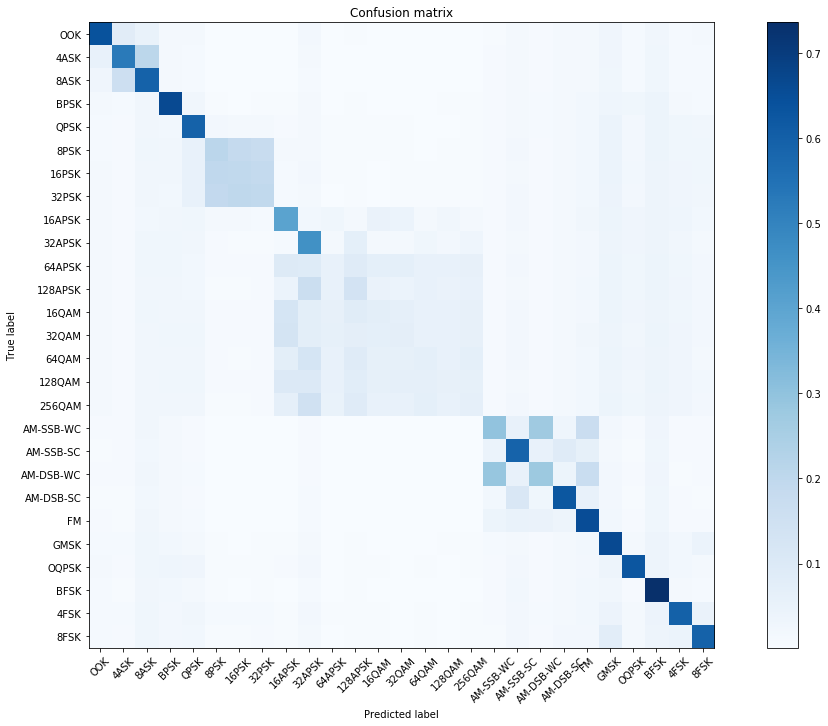

In [15]:
plot_confusion_matrix(confnorm, labels=classes)

In [ ]:
super_classes = ["OOK", 
                 "M-ASK",
                 "M-PSK",  
                 "M-APSK", 
                 "M-QAM", 
                 "AM", 
                 "FM", 
                 "GMSK", 
                 "OQPSK",
                 "M-FSK"] 

In [ ]:
# Plot confusion matrix for the modulation schemes' super classes
test_Y_hat = best_model.predict(hp.TEST_DATA, batch_size=hp.TRAIN_BATCH_SIZE)

super_class_labels_hat = np.zeros((test_Y_hat.shape[0], 10), dtype=int)
for i in range(test_Y_hat.shape[0]):
    super_class_labels_hat[i] = map_to_super_classes(test_Y_hat[i], super_class_mapping)

conf = np.zeros([10,10])
confnorm = np.zeros([10,10])
for i in range(0,hp.TEST_DATA.shape[0]):
    j = list(super_class_labels[i,:]).index(1)
    k = int(np.argmax(super_class_labels_hat[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,10):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

(287540, 10)


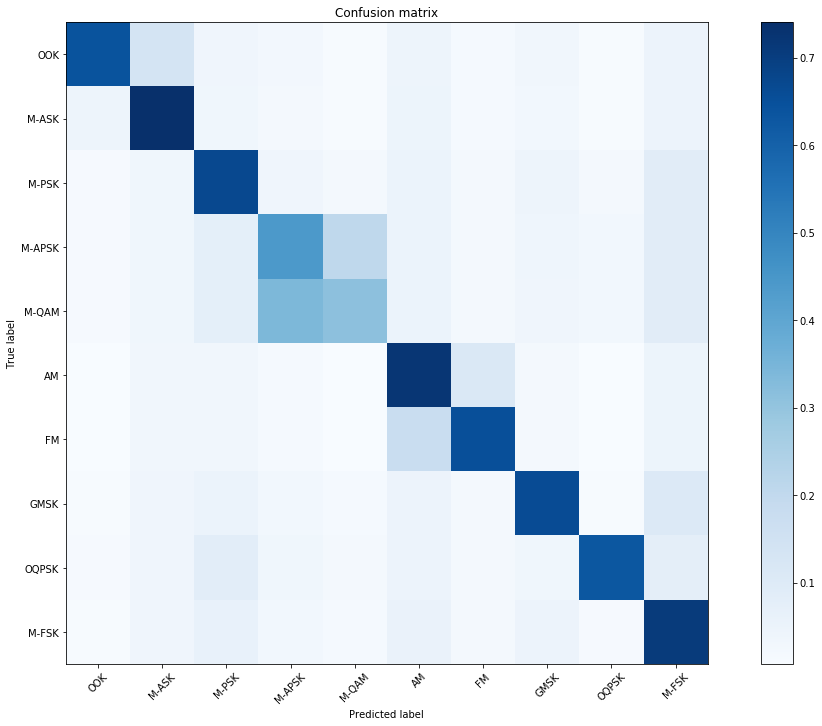

In [30]:
plot_confusion_matrix(confnorm, labels=super_classes)

In [31]:
Y_pred = best_model.predict(hp.TEST_DATA,batch_size=hp.TRAIN_BATCH_SIZE)
y_pred = np.argmax(Y_pred, axis = 1)
y_actual = np.argmax(hp.TEST_LABELS, axis = 1)
classificationreport_fp = classification_report(y_actual,y_pred, target_names=classes)
print(classificationreport_fp)

              precision    recall  f1-score   support

         OOK       0.63      0.64      0.64     10486
        4ASK       0.55      0.52      0.54     10721
        8ASK       0.40      0.59      0.48     10559
        BPSK       0.53      0.66      0.59     10512
        QPSK       0.49      0.59      0.54     10643
        8PSK       0.28      0.21      0.24     10804
       16PSK       0.27      0.20      0.23     10685
       32PSK       0.28      0.19      0.23     10688
      16APSK       0.36      0.40      0.38     10826
      32APSK       0.30      0.46      0.37     10664
      64APSK       0.12      0.06      0.08     10564
     128APSK       0.17      0.13      0.15     10730
       16QAM       0.13      0.07      0.09     10670
       32QAM       0.13      0.07      0.09     10633
       64QAM       0.13      0.07      0.09     10699
      128QAM       0.12      0.06      0.08     10673
      256QAM       0.12      0.07      0.09     10505
   AM-SSB-WC       0.34    

In [32]:
batchsize = 1024
snrlist = np.unique(hp.TEST_SNRS)
acc_snr_arr = []

# interate over SNRs
for snr in tqdm(snrlist):
    acc_arr = []
    i_SNR = np.where(hp.TEST_SNRS==snr)
    X_SNR = hp.TEST_DATA[i_SNR[0],:,:]
    Y_SNR = hp.TEST_LABELS[i_SNR[0],:]
    X_SNR_len = np.shape(X_SNR)[0]
    total_batches = int(X_SNR_len/batchsize)
    
    for i in (range(0, total_batches)):
        x_batch, y_batch = X_SNR[i*batchsize:i*batchsize+batchsize], Y_SNR[i*batchsize:i*batchsize+batchsize]
        
        # model prediction
        pred = best_model.predict(x_batch)
        
        #Pediction values are onehote, corresponding to indices representing different modulation types
        pred_ind = np.argmax(pred, axis=1)
        expected_ind = np.argmax(y_batch, axis=1)
        matches  = sum(np.equal(pred_ind, expected_ind))
        acc      = matches/batchsize
        acc_arr.append(acc)

    # Average the per-batch accuracy values
    accuracy = np.mean(acc_arr)
    acc_snr_arr.append(accuracy)
    print("SNR: ", snr, "accuracy", accuracy)

  4%|▍         | 1/26 [00:00<00:13,  1.84it/s]

SNR:  -20 accuracy 0.036328125


  8%|▊         | 2/26 [00:00<00:12,  1.96it/s]

SNR:  -18 accuracy 0.0337890625


 12%|█▏        | 3/26 [00:01<00:11,  2.05it/s]

...

SNR:  26 accuracy 0.61708984375


 96%|█████████▌| 25/26 [00:10<00:00,  2.30it/s]

SNR:  28 accuracy 0.61767578125


100%|██████████| 26/26 [00:11<00:00,  2.31it/s]

SNR:  30 accuracy 0.611328125


<Figure size 72x72 with 0 Axes>

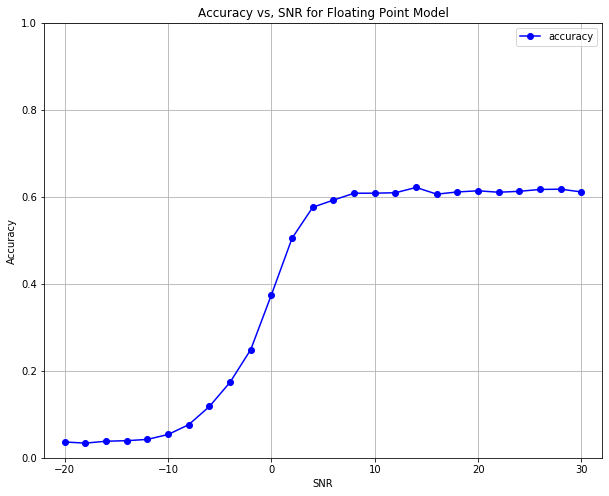

In [33]:
plt.figure(figsize=(1,1))
plt.show()
fig= plt.figure(figsize=(10,8))
plt.plot(snrlist, acc_snr_arr, 'bo-', label='accuracy')
plt.ylabel('Accuracy')
plt.xlabel('SNR')
plt.title("Accuracy vs, SNR for Floating Point Model")
plt.legend()
plt.axis([-22, 32, 0, 1.0])
plt.grid()

In [41]:
batchsize = 400
snrlist = np.sort(np.unique(hp.TEST_SNRS))
modlist = np.unique(hp.TEST_LABELS, axis = 0)
accuracy_mod_snr = np.empty((26, 27))

# Generator just cuz
def my_ranger_array(helperArray: any):
    index = 0
    while index < len(helperArray):
        yield helperArray[index]
        index += 1
        
# For each SNR
for idx, snr in enumerate(my_ranger_array(snrlist)):
    i_SNR = np.where(hp.TEST_SNRS==snr)
    X_SNR = hp.TEST_DATA[i_SNR[0], :, :]
    Y_SNR = hp.TEST_LABELS[i_SNR[0], :]  

    # For each mod
    for mod_index in range(27):
        mod = modlist[mod_index]
        mod_name = classes[np.where(mod == 1)[0][0]]
        i_SNR_MOD = np.where(np.all(Y_SNR == mod, axis=1))[0]
        X_SNR_MOD = X_SNR[i_SNR_MOD,:,:]      
        Y_SNR_MOD = Y_SNR[i_SNR_MOD,:]
        X_SNR_MOD_len = np.shape(X_SNR_MOD)[0]
        total_batches = int(X_SNR_MOD_len/batchsize)
        for k in range(0, total_batches):
            x_batch, y_batch = X_SNR_MOD[k * batchsize : k * batchsize + batchsize], Y_SNR_MOD[k * batchsize : k * batchsize + batchsize]
            pred = best_model.predict(x_batch)
            pred_ind = np.argmax(pred, axis = 1)
            expected_ind = np.argmax(y_batch, axis = 1)
            accuracy = sum(np.equal(pred_ind, expected_ind)) / batchsize
            accuracy_mod_snr[idx, mod_index] = accuracy

<Figure size 72x72 with 0 Axes>

ValueError: x and y must have same first dimension, but have shapes (26,) and (27,)

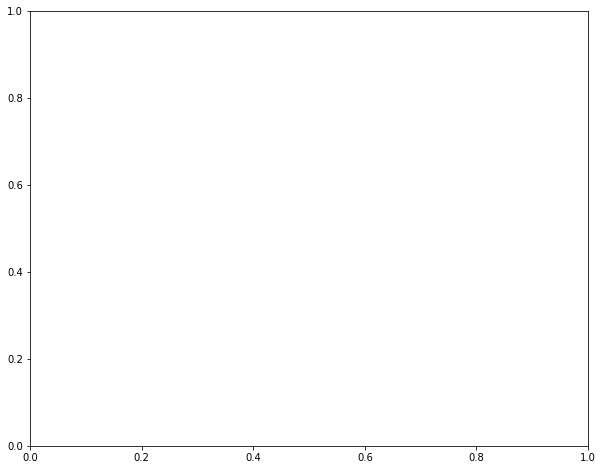

In [ ]:
plt.figure(figsize=(1,1))
plt.show()
fig= plt.figure(figsize=(10,8))

accuracy_mod_snr = np.transpose(accuracy_mod_snr)
print(np.shape(accuracy_mod_snr))

for mod in range(27): 
    color = 'Black' if ((accuracy_mod_snr[mod][-13] > 0.9) and (accuracy_mod_snr[mod][0] < 0.2)) else None
    # print("SNR list: ", np.shape(snrlist))
    # print(np.shape(accuracy_mod_snr[mod]))
    plt.plot(snrlist, accuracy_mod_snr[mod], label=str(mod) + ": " + classes[mod], color=color)
    
plt.ylabel('Accuracy')
plt.xlabel('SNR')
plt.title("Accuracy vs, SNR for Floating Point Model")
plt.legend()
plt.axis([-22, 32, 0, 1.0])
plt.grid()

In [4]:
train_data = hp.TRAIN_DATA
train_labels = hp.TRAIN_LABELS
test_data = hp.TEST_DATA
test_labels = hp.TEST_LABELS
val_data = hp.VAL_DATA
val_labels = hp.VAL_LABELS